In [1]:
print("Data Science & AI/ML Practical Exam")
print("Set C")
print("Predict late deliveries and identify operational segments")

Data Science & AI/ML Practical Exam
Set C
Predict late deliveries and identify operational segments


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import sklearn
import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

NumPy: 2.4.3
Pandas: 3.0.1
SciPy: 1.16.3
Scikit-learn: 1.8.0
TensorFlow: 2.21.0


In [4]:
import matplotlib

print("Matplotlib version:", matplotlib.__version__)

Matplotlib version: 3.11.2


In [5]:
import pandas as pd

df_raw = pd.read_csv("../data/raw/set_b.csv")

df_raw.head()

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


In [6]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nColumn Names:")
print(df_raw.columns.tolist())

print("\nMissing Values:")
print(df_raw.isna().sum())

print("\nDuplicate Rows:")
print(df_raw.duplicated().sum())

print("\nTarget Distribution:")
print(df_raw["late"].value_counts())

Rows: 305
Columns: 7

Column Names:
['record_id', 'distance', 'load', 'traffic', 'staff', 'group', 'late']

Missing Values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Duplicate Rows:
5

Target Distribution:
late
0    156
1    149
Name: count, dtype: int64


In [7]:
import pandas as pd

df_raw = pd.read_csv("../data/raw/set_b.csv")

print("Dataset Shape:", df_raw.shape)

print("\nColumns:")
print(df_raw.columns.tolist())

print("\nMissing Values:")
print(df_raw.isna().sum())

print("\nDuplicate Rows:")
print(df_raw.duplicated().sum())

print("\nTarget Distribution:")
print(df_raw["late"].value_counts())

Dataset Shape: (305, 7)

Columns:
['record_id', 'distance', 'load', 'traffic', 'staff', 'group', 'late']

Missing Values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Duplicate Rows:
5

Target Distribution:
late
0    156
1    149
Name: count, dtype: int64


In [8]:
df_raw.head()

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   record_id  305 non-null    int64  
 1   distance   290 non-null    float64
 2   load       290 non-null    float64
 3   traffic    305 non-null    float64
 4   staff      305 non-null    float64
 5   group      305 non-null    str    
 6   late       305 non-null    int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 16.8 KB


In [10]:
# Remove exact duplicate rows
df = df_raw.drop_duplicates().copy()

print("Shape before removing duplicates:", df_raw.shape)
print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())
print("Unique record IDs:", df["record_id"].nunique())

Shape before removing duplicates: (305, 7)
Shape after removing duplicates: (300, 7)
Remaining duplicates: 0
Unique record IDs: 300


In [11]:
print("Clean Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isna().sum())

print("\nTarget Distribution:")
print(df["late"].value_counts())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Clean Dataset Shape: (300, 7)

Missing Values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Target Distribution:
late
0    155
1    145
Name: count, dtype: int64

Duplicate Rows:
0


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["late"]
)

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)

Training data: (240, 7)
Test data: (60, 7)


In [16]:
fit_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["late"]
)

print("Fit data:", fit_df.shape)
print("Validation data:", val_df.shape)
print("Test data:", test_df.shape)
print("Target Distribution in Fit Data:")
print(fit_df["late"].value_counts())


Fit data: (192, 7)
Validation data: (48, 7)
Test data: (60, 7)
Target Distribution in Fit Data:
late
0    99
1    93
Name: count, dtype: int64


In [17]:
print("Fit:", len(fit_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(fit_df) + len(val_df) + len(test_df))

Fit: 192
Validation: 48
Test: 60

Total: 300


In [18]:
print("FIT target:")
print(fit_df["late"].value_counts())

print("\nVALIDATION target:")
print(val_df["late"].value_counts())

print("\nTEST target:")
print(test_df["late"].value_counts())

FIT target:
late
0    99
1    93
Name: count, dtype: int64

VALIDATION target:
late
0    25
1    23
Name: count, dtype: int64

TEST target:
late
0    31
1    29
Name: count, dtype: int64


In [19]:
fit_ids = set(fit_df["record_id"])
val_ids = set(val_df["record_id"])
test_ids = set(test_df["record_id"])

print("Fit ∩ Validation:", fit_ids.intersection(val_ids))
print("Fit ∩ Test:", fit_ids.intersection(test_ids))
print("Validation ∩ Test:", val_ids.intersection(test_ids))

Fit ∩ Validation: set()
Fit ∩ Test: set()
Validation ∩ Test: set()


In [21]:
assert len(fit_ids.intersection(val_ids)) == 0
assert len(fit_ids.intersection(test_ids)) == 0
assert len(val_ids.intersection(test_ids)) == 0

print("All partitions are completely disjoint.")

All partitions are completely disjoint.


In [22]:
import os

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

In [25]:
splits = pd.concat([
    fit_df[["record_id"]].assign(partition="fit"),
    val_df[["record_id"]].assign(partition="validation"),
    test_df[["record_id"]].assign(partition="test")
])

splits.to_csv("../outputs/splits.csv", index=False)

print("Saved:", "../outputs/splits.csv")
print("Fit data:", fit_df.shape)
print("validation data:", val_df.shape)

Saved: ../outputs/splits.csv
Fit data: (192, 7)
validation data: (48, 7)


# 1. Maths & Advanced Statistics

All statistical calculations in this section use only the 192 fit records.

For statistical calculations, missing values are not imputed.
Only observed values are used.

In [26]:
distance_observed = fit_df["distance"].dropna()

## M1 — Descriptive Statistics

We calculate descriptive statistics for `distance` using only the observed
(non-missing) values from the 192 fit records.

The required statistics are:
- Observed sample size (n)
- Mean
- Median
- Sample standard deviation (ddof=1)

In [27]:
# Select observed distance values from the 192 fit records
distance_observed = fit_df["distance"].dropna()

# Calculate descriptive statistics
distance_n = distance_observed.count()
distance_mean = distance_observed.mean()
distance_median = distance_observed.median()
distance_std = distance_observed.std(ddof=1)

print("Distance Descriptive Statistics")
print("--------------------------------")
print("Observed n:", distance_n)
print("Mean:", distance_mean)
print("Median:", distance_median)
print("Sample Standard Deviation:", distance_std)

Distance Descriptive Statistics
--------------------------------
Observed n: 184
Mean: 49.74440217391305
Median: 50.2
Sample Standard Deviation: 10.835872254207478


result in table format

In [28]:
descriptive_summary = pd.DataFrame({
    "Statistic": [
        "Observed n",
        "Mean",
        "Median",
        "Sample Standard Deviation"
    ],
    "Value": [
        distance_n,
        distance_mean,
        distance_median,
        distance_std
    ]
})

descriptive_summary

,Statistic,Value
0,Observed n,184.000000
1,Mean,49.744402
2,Median,50.200000
3,Sample Standard Deviation,10.835872


### Distance Histogram

The histogram shows the distribution of the observed `distance` values
in the fit dataset. Missing distance values are excluded.

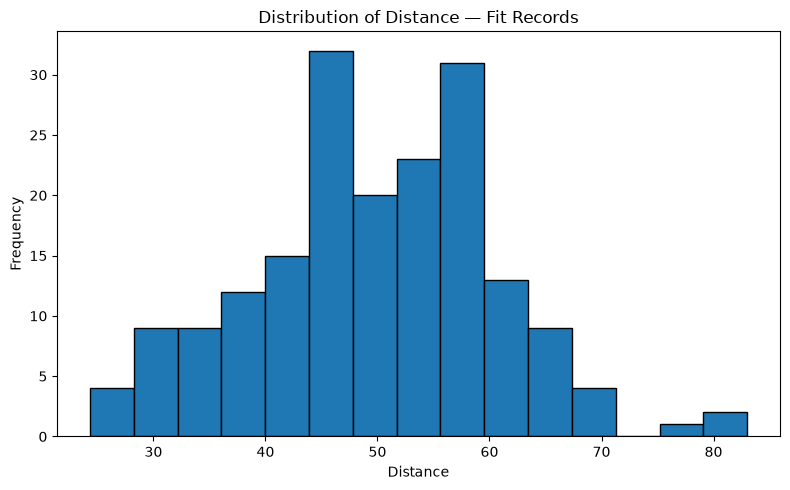

In [29]:
import os
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 5))

# Plot histogram
plt.hist(
    distance_observed,
    bins=15,
    edgecolor="black"
)

# Add title and labels
plt.title("Distribution of Distance — Fit Records")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/distance_histogram.png",
    dpi=150
)

plt.show()

## M2 — Statistical Inference

### Welch's Two-Sample t-test

We compare the mean observed distance between operational groups G1 and G2.

**H0:** μG1 = μG2

**H1:** μG1 ≠ μG2

Significance level:

α = 0.05

A two-sided Welch t-test is used because the two groups are compared
without assuming equal population variances.

In [30]:
# Observed distance values for G1
g1_distance = fit_df.loc[
    (fit_df["group"] == "G1") &
    (fit_df["distance"].notna()),
    "distance"
]

# Observed distance values for G2
g2_distance = fit_df.loc[
    (fit_df["group"] == "G2") &
    (fit_df["distance"].notna()),
    "distance"
]

print("G1 observed n:", len(g1_distance))
print("G2 observed n:", len(g2_distance))

print("\nG1 mean distance:", g1_distance.mean())
print("G2 mean distance:", g2_distance.mean())

G1 observed n: 104
G2 observed n: 80

G1 mean distance: 50.24048076923077
G2 mean distance: 49.0995


Step 2 — Perform Welch test

In [31]:
from scipy import stats

t_statistic, p_value = stats.ttest_ind(
    g1_distance,
    g2_distance,
    equal_var=False
)

print("Welch's t-test")
print("--------------")
print("t-statistic:", t_statistic)
print("p-value:", p_value)

Welch's t-test
--------------
t-statistic: 0.7061612423464614
p-value: 0.48105881393425987


Step 3 — Decision at α = 0.05

In [32]:
alpha = 0.05

if p_value < alpha:
    decision = "Reject H0"
    interpretation = (
        "There is statistically significant evidence of a difference "
        "in mean observed distance between G1 and G2."
    )
else:
    decision = "Fail to reject H0"
    interpretation = (
        "There is insufficient statistical evidence of a difference "
        "in mean observed distance between G1 and G2."
    )

print("Decision:", decision)
print("Interpretation:", interpretation)

Decision: Fail to reject H0
Interpretation: There is insufficient statistical evidence of a difference in mean observed distance between G1 and G2.


### 95% Confidence Interval for Mean Distance

A 95% t-confidence interval is calculated for the overall observed
mean distance using the fit records.

Only observed distance values are used; missing values are excluded.

In [33]:
# Sample size
n = len(distance_observed)

# Sample mean
mean = distance_observed.mean()

# Sample standard deviation
std = distance_observed.std(ddof=1)

# Significance level
alpha = 0.05

# Degrees of freedom
df_ci = n - 1

# Critical t-value
t_critical = stats.t.ppf(
    1 - alpha / 2,
    df=df_ci
)

# Standard error
standard_error = std / np.sqrt(n)

# Margin of error
margin_error = t_critical * standard_error

# Confidence interval
ci_lower = mean - margin_error
ci_upper = mean + margin_error

print("95% Confidence Interval")
print("-----------------------")
print("Observed n:", n)
print("Mean:", mean)
print("Standard deviation:", std)
print("Degrees of freedom:", df_ci)
print("t-critical:", t_critical)
print("Standard error:", standard_error)
print("Margin of error:", margin_error)
print("Lower bound:", ci_lower)
print("Upper bound:", ci_upper)

95% Confidence Interval
-----------------------
Observed n: 184
Mean: 49.74440217391305
Standard deviation: 10.835872254207478
Degrees of freedom: 183
t-critical: 1.973011915132679
Standard error: 0.7988311009024627
Margin of error: 1.5761032802591142
Lower bound: 48.16829889365394
Upper bound: 51.320505454172164


M2 Final Result Table 

In [36]:
inference_summary = pd.DataFrame({
    "Metric": [
        "G1 observed n",
        "G2 observed n",
        "G1 mean",
        "G2 mean",
        "Welch t-statistic",
        "Welch p-value",
        "Alpha",
        "95% CI lower",
        "95% CI upper"
    ],
    "Value": [
        len(g1_distance),
        len(g2_distance),
        g1_distance.mean(),
        g2_distance.mean(),
        t_statistic,
        p_value,
        alpha,
        ci_lower,
        ci_upper
    ]
})

inference_summary

,Metric,Value
0,G1 observed n,104.000000
1,G2 observed n,80.000000
2,G1 mean,50.240481
3,G2 mean,49.099500
4,Welch t-statistic,0.706161
5,Welch p-value,0.481059
6,Alpha,0.050000
7,95% CI lower,48.168299
8,95% CI upper,51.320505


## M3 — Linear Algebra

We use only fit records that have observed values for both `distance`
and `traffic`.

The two-column matrix is:

X = [distance, traffic]

The matrix is manually centered by subtracting the column means.
Then the sample covariance matrix is calculated using:

Cov(X) = X_centered.T @ X_centered / (n - 1)

In [37]:
# Select distance and traffic
linear_df = fit_df[["distance", "traffic"]].dropna()

print("Complete rows:", len(linear_df))

print("\nFirst 5 rows:")
print(linear_df.head())

Complete rows: 184

First 5 rows:
     distance  traffic
288     55.85    42.44
73      51.75    36.39
259     58.99    65.07
280     58.04    53.20
243     57.60    37.48


M3 Step2 

In [38]:
X = linear_df[["distance", "traffic"]].to_numpy()

print("Matrix shape:", X.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

Matrix shape: (184, 2)

First 5 rows of X:
[[55.85 42.44]
 [51.75 36.39]
 [58.99 65.07]
 [58.04 53.2 ]
 [57.6  37.48]]


# M3 Step 3 — Calculate column means

In [41]:
X = linear_df[["distance", "traffic"]].to_numpy()

print("Matrix shape:", X.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

Matrix shape: (184, 2)

First 5 rows of X:
[[55.85 42.44]
 [51.75 36.39]
 [58.99 65.07]
 [58.04 53.2 ]
 [57.6  37.48]]


## M3 — Linear Algebra

We use only fit records that have observed values for both `distance`
and `traffic`.

The two-column matrix is:

X = [distance, traffic]

The matrix is manually centered by subtracting the column means.
Then the sample covariance matrix is calculated using:

Cov(X) = X_centered.T @ X_centered / (n - 1)

In [34]:
# Select distance and traffic
linear_df = fit_df[["distance", "traffic"]].dropna()

print("Complete rows:", len(linear_df))

print("\nFirst 5 rows:")
print(linear_df.head())

Complete rows: 184

First 5 rows:
     distance  traffic
288     55.85    42.44
73      51.75    36.39
259     58.99    65.07
280     58.04    53.20
243     57.60    37.48


Task 2 — Data Preprocessing & Feature Engineering (5 Marks)
F1 — Audit and Partition (2 Marks)
Report shape, exact duplicates, missing counts and target counts; verify 300 unique records after cleaning (1). Create the specified fit/validation/test partitions, save their IDs, and prove they are disjoint (1).
F2 — Transform and Engineer (2 Marks)
Fit median imputation on numeric fit columns and one-hot encode group, handling unseen categories; transform validation/test without refitting (1). Create the specified engineered feature, then fit standard scaling on fit numeric features only; reuse it unchanged elsewhere (1). Keep group one-hot columns unscaled.
F3 — Leakage Evidence (1 Mark)
Print transformed shapes and feature names; verify finite numeric outputs. Explain why the target, record_id and test statistics are excluded from training. Save fitted preprocessing or provide executable code that recreates it.


## F1 — Data Audit and Partition

The raw dataset contains 305 rows, including 5 exact duplicate rows.
After removing exact duplicates, the cleaned dataset contains 300 unique
records.

The target variable is `late`, where:
- 0 = not late
- 1 = late

In [45]:
fit_df
val_df
test_df

,record_id,distance,load,traffic,staff,group,late
49,50,38.02,52.00,45.50,60.11,G1,0
230,231,50.83,37.57,45.90,51.97,G1,0
296,297,30.51,31.39,42.99,50.60,G2,0
96,97,51.61,45.89,46.84,67.67,G2,0
284,285,NaN,62.29,39.01,70.44,G1,0
115,116,55.10,50.29,51.24,52.38,G2,0
37,38,54.78,53.21,64.07,54.65,G2,1
75,76,NaN,35.69,33.24,40.38,G1,0
50,51,49.18,54.71,64.44,49.26,G1,1
99,100,47.45,40.13,50.64,56.67,G1,0


In [46]:
print("PARTITION SIZES")
print("----------------")
print("Fit:", len(fit_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(fit_df) + len(val_df) + len(test_df))

PARTITION SIZES
----------------
Fit: 192
Validation: 48
Test: 60

Total: 300


### Partition Disjointness

The record IDs are checked to ensure that no record appears in more than
one partition.

In [47]:
fit_ids = set(fit_df["record_id"])
val_ids = set(val_df["record_id"])
test_ids = set(test_df["record_id"])

print("Fit ∩ Validation:", fit_ids.intersection(val_ids))
print("Fit ∩ Test:", fit_ids.intersection(test_ids))
print("Validation ∩ Test:", val_ids.intersection(test_ids))

Fit ∩ Validation: set()
Fit ∩ Test: set()
Validation ∩ Test: set()


In [48]:
assert len(fit_ids.intersection(val_ids)) == 0
assert len(fit_ids.intersection(test_ids)) == 0
assert len(val_ids.intersection(test_ids)) == 0

print("All partitions are disjoint.")

All partitions are disjoint.


Step 3 — Save partition IDs

In [49]:
import os

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

splits = pd.concat([
    fit_df[["record_id"]].assign(partition="fit"),
    val_df[["record_id"]].assign(partition="validation"),
    test_df[["record_id"]].assign(partition="test")
])

splits.to_csv("../outputs/splits.csv", index=False)

print("Saved outputs/splits.csv")

Saved outputs/splits.csv


F2 — Transform and Engineer

## F2 — Feature Engineering and Preprocessing

### Predictor columns

Numeric predictors:
- distance
- load
- traffic
- staff

Categorical predictor:
- group

The identifier `record_id` and target `late` are excluded from model inputs.

The engineered feature is:

engineered_feature = load / (staff + 1)

The engineered feature is calculated after numeric imputation and before
standard scaling.

In [50]:
numeric_features = [
    "distance",
    "load",
    "traffic",
    "staff"
]

categorical_features = [
    "group"
]

target = "late"
id_column = "record_id"

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)
print("ID:", id_column)

Numeric features: ['distance', 'load', 'traffic', 'staff']
Categorical features: ['group']
Target: late
ID: record_id


# Step 2 — Median Imputation

In [56]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(
    strategy="median"
)

numeric_imputer.fit(
    fit_df[numeric_features]
)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [60]:
imputation_values = pd.Series(
    numeric_imputer.statistics_,
    index=numeric_features
)

print("Median values learned from FIT data:")
print(imputation_values)

Median values learned from FIT data:
distance    50.200
load        49.965
traffic     49.635
staff       50.265
dtype: float64


## Step 3 — Impute all three datasets

In [61]:
fit_numeric_imputed = numeric_imputer.transform(
    fit_df[numeric_features]
)

val_numeric_imputed = numeric_imputer.transform(
    val_df[numeric_features]
)

test_numeric_imputed = numeric_imputer.transform(
    test_df[numeric_features]
)

# Step 4 — DataFrame

In [62]:
fit_numeric_imputed = pd.DataFrame(
    fit_numeric_imputed,
    columns=numeric_features,
    index=fit_df.index
)

val_numeric_imputed = pd.DataFrame(
    val_numeric_imputed,
    columns=numeric_features,
    index=val_df.index
)

test_numeric_imputed = pd.DataFrame(
    test_numeric_imputed,
    columns=numeric_features,
    index=test_df.index
)

In [63]:
print("Fit missing values:")
print(fit_numeric_imputed.isna().sum())

print("\nValidation missing values:")
print(val_numeric_imputed.isna().sum())

print("\nTest missing values:")
print(test_numeric_imputed.isna().sum())

Fit missing values:
distance    0
load        0
traffic     0
staff       0
dtype: int64

Validation missing values:
distance    0
load        0
traffic     0
staff       0
dtype: int64

Test missing values:
distance    0
load        0
traffic     0
staff       0
dtype: int64


Step 5 — Engineered Feature

In [64]:
fit_numeric_imputed["engineered_feature"] = (
    fit_numeric_imputed["load"] /
    (fit_numeric_imputed["staff"] + 1)
)

val_numeric_imputed["engineered_feature"] = (
    val_numeric_imputed["load"] /
    (val_numeric_imputed["staff"] + 1)
)

test_numeric_imputed["engineered_feature"] = (
    test_numeric_imputed["load"] /
    (test_numeric_imputed["staff"] + 1)
)    

In [65]:
print(fit_numeric_imputed.head())

     distance    load  traffic  staff  engineered_feature
288     55.85  54.680    42.44  54.95            0.977301
73      51.75  47.550    36.39  36.13            1.280636
259     58.99  38.830    65.07  53.74            0.709353
280     58.04  37.760    53.20  53.97            0.686920
243     57.60  49.965    37.48  57.45            0.854833


# Step 6 — One-Hot Encoding

In [66]:
from sklearn.preprocessing import OneHotEncoder

group_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

group_encoder.fit(
    fit_df[["group"]]
)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [69]:
group_feature_names = group_encoder.get_feature_names_out(
    ["group"]
)

print("Encoded columns:")
print(group_feature_names)

Encoded columns:
['group_G1' 'group_G2']


#Step 7 — Why group columns remain unscaled

# Step 8 — StandardScaler

In [70]:
scaled_numeric_features = [
    "distance",
    "load",
    "traffic",
    "staff",
    "engineered_feature"
]

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [72]:
scaler.fit(
    fit_numeric_imputed[scaled_numeric_features]
)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [73]:
fit_numeric_scaled = scaler.transform(
    fit_numeric_imputed[scaled_numeric_features]
)

val_numeric_scaled = scaler.transform(
    val_numeric_imputed[scaled_numeric_features]
)

test_numeric_scaled = scaler.transform(
    test_numeric_imputed[scaled_numeric_features]
)

# Step 9 — Combine numeric + group features

In [74]:
fit_numeric_scaled = pd.DataFrame(
    fit_numeric_scaled,
    columns=scaled_numeric_features,
    index=fit_df.index
)

val_numeric_scaled = pd.DataFrame(
    val_numeric_scaled,
    columns=scaled_numeric_features,
    index=val_df.index
)

test_numeric_scaled = pd.DataFrame(
    test_numeric_scaled,
    columns=scaled_numeric_features,
    index=test_df.index
)

In [77]:
fit_group_encoded = group_encoder.transform(
    fit_df[["group"]]
)

fit_group_encoded = pd.DataFrame(
    fit_group_encoded,
    columns=group_feature_names,
    index=fit_df.index
)

val_group_encoded = pd.DataFrame(
    group_encoder.transform(val_df[["group"]]),
    columns=group_feature_names,
    index=val_df.index
)

test_group_encoded = pd.DataFrame(
    group_encoder.transform(test_df[["group"]]),
    columns=group_feature_names,
    index=test_df.index
)

val_group_encoded = pd.DataFrame(
    val_group_encoded,
    columns=group_feature_names,
    index=val_df.index
)

test_group_encoded = pd.DataFrame(
    test_group_encoded,
    columns=group_feature_names,
    index=test_df.index
)

 Step 10 — Final transformed datasets

In [78]:
X_fit = pd.concat(
    [
        fit_numeric_scaled,
        fit_group_encoded
    ],
    axis=1
)

In [79]:
X_val = pd.concat(
    [
        val_numeric_scaled,
        val_group_encoded
    ],
    axis=1
)

In [80]:
X_test = pd.concat(
    [
        test_numeric_scaled,
        test_group_encoded
    ],
    axis=1
)

In [81]:
y_fit = fit_df["late"].to_numpy()

y_val = val_df["late"].to_numpy()

y_test = test_df["late"].to_numpy()

# F3 — Leakage Evidence

In [82]:
print("X_fit shape:", X_fit.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nTarget shapes:")
print("y_fit:", y_fit.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_fit shape: (192, 7)
X_val shape: (48, 7)
X_test shape: (60, 7)

Target shapes:
y_fit: (192,)
y_val: (48,)
y_test: (60,)


In [83]:
feature_names = X_fit.columns.tolist()

print("Final model features:")
for i, feature in enumerate(feature_names, start=1):
    print(i, "->", feature)

Final model features:
1 -> distance
2 -> load
3 -> traffic
4 -> staff
5 -> engineered_feature
6 -> group_G1
7 -> group_G2


In [84]:
print("Fit finite:", np.isfinite(X_fit.to_numpy()).all())
print("Validation finite:", np.isfinite(X_val.to_numpy()).all())
print("Test finite:", np.isfinite(X_test.to_numpy()).all())

Fit finite: True
Validation finite: True
Test finite: True


In [85]:
import joblib

preprocessing_objects = {
    "numeric_imputer": numeric_imputer,
    "group_encoder": group_encoder,
    "scaler": scaler,
    "numeric_features": numeric_features,
    "scaled_numeric_features": scaled_numeric_features,
    "group_feature_names": list(group_feature_names)
}

joblib.dump(
    preprocessing_objects,
    "../models/preprocessing.pkl"
)

print("Saved preprocessing to ../models/preprocessing.pkl")

Saved preprocessing to ../models/preprocessing.pkl


In [86]:
scaler.fit(X_fit)

X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [89]:
print("=" * 50)
print("TASK 2 — FINAL PREPROCESSING AUDIT")
print("=" * 50)

print("\nPartition sizes:")
print("Fit:", X_fit.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nFeature names:")
print(feature_names)

print("\nFinite checks:")
print("Fit:", np.isfinite(X_fit.to_numpy()).all())
print("\nFinite checks:")
print("Fit:", np.isfinite(np.asarray(X_fit)).all())
print("Validation:", np.isfinite(np.asarray(X_val)).all())
print("Test:", np.isfinite(np.asarray(X_test)).all())
print("Test:", np.isfinite(np.asarray(X_test)).all())

print("\nPreprocessing objects:")
print("Median Imputer: FIT only")
print("One-Hot Encoder: FIT only")
print("Standard Scaler: FIT only")

print("\nTarget and record_id excluded from model features: YES")

TASK 2 — FINAL PREPROCESSING AUDIT

Partition sizes:
Fit: (192, 7)
Validation: (48, 7)
Test: (60, 7)

Feature names:
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']

Finite checks:
Fit: True

Finite checks:
Fit: True
Validation: True
Test: True
Test: True

Preprocessing objects:
Median Imputer: FIT only
One-Hot Encoder: FIT only
Standard Scaler: FIT only

Target and record_id excluded from model features: YES


# 3. Supervised Learning

The target variable is `late`.

- `late = 1` means the delivery is late.
- `late = 0` means the delivery is not late.

The predictors are the transformed features created in Task 2:
- distance
- load
- traffic
- staff
- engineered_feature
- group one-hot encoded features

`record_id` is excluded because it is only an identifier.
The target `late` is excluded from the predictors.

Two models are used:

1. Majority-class DummyClassifier as the baseline
2. LogisticRegression as the predictive classifier

Both models are trained only on the 192 fit records.
The 60 test records remain untouched until final evaluation.

## S1 — Baseline Model

A majority-class DummyClassifier is used as a simple baseline.

The baseline always predicts the most frequent target class observed
in the fit partition.

This provides a reference point for evaluating whether Logistic Regression
learns useful predictive patterns beyond simply predicting the majority class.

In [90]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_fit,
    y_fit
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


## Logistic Regression

Logistic Regression is used as the main supervised classification model.

Model settings:
- max_iter = 1000
- random_state = 42
- Classification threshold = 0.5

The model is trained only on the 192 fit records.

In [91]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_fit,
    y_fit
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [92]:
print("Target:")
print(target)

print("\nPredictors:")
for feature in feature_names:
    print("-", feature)

print("\nLogistic Regression settings:")
print("max_iter:", logistic_model.max_iter)
print("random_state:", logistic_model.random_state)

print("\nTraining records:")
print("Fit records:", len(X_fit))

Target:
late

Predictors:
- distance
- load
- traffic
- staff
- engineered_feature
- group_G1
- group_G2

Logistic Regression settings:
max_iter: 1000
random_state: 42

Training records:
Fit records: 192


## S2 — Holdout Evaluation

The test partition contains 60 records and was not used during preprocessing
fitting or model training.

The final evaluation uses a classification threshold of 0.5.

A predicted probability >= 0.5 is classified as late (`1`).
A probability < 0.5 is classified as not late (`0`).

In [93]:
dummy_pred = dummy_model.predict(X_test)

In [94]:
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [95]:
logistic_pred = (
    logistic_proba >= 0.5
).astype(int)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    pos_label=1,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    pos_label=1,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    pos_label=1,
    zero_division=0
)

print("Logistic Regression — Test Metrics")
print("-----------------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression — Test Metrics
-----------------------------------
Accuracy : 0.85
Precision: 0.8571428571428571
Recall   : 0.8275862068965517
F1 Score : 0.8421052631578947


In [97]:
dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

print("Dummy baseline accuracy:", dummy_accuracy)

Dummy baseline accuracy: 0.5166666666666667


In [98]:
comparison = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "LogisticRegression"
    ],
    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy
    ],
    "Precision": [
        np.nan,
        logistic_precision
    ],
    "Recall": [
        np.nan,
        logistic_recall
    ],
    "F1": [
        np.nan,
        logistic_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,DummyClassifier,0.516667,NaN,NaN,NaN
1,LogisticRegression,0.850000,0.857143,0.827586,0.842105


In [99]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    logistic_pred,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[27  4]
 [ 5 24]]


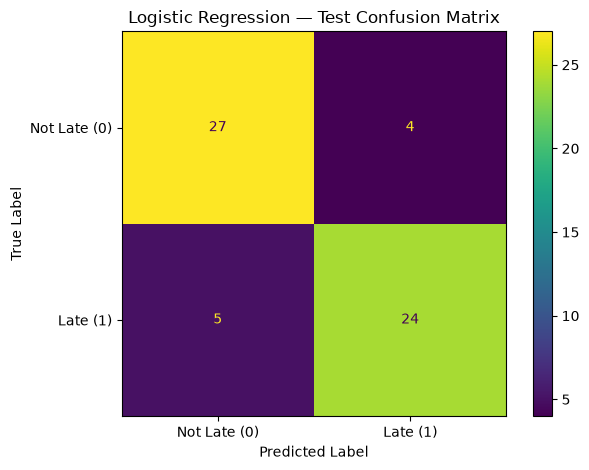

In [100]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late (0)", "Late (1)"]
)

disp.plot()

plt.title("Logistic Regression — Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/logistic_confusion_matrix.png",
    dpi=150
)

plt.show()

In [101]:
test_predictions = pd.DataFrame({
    "record_id": test_df["record_id"].values,
    "true_label": y_test,
    "predicted_label": logistic_pred,
    "class_1_probability": logistic_proba
})

test_predictions.head(10)

,record_id,true_label,predicted_label,class_1_probability
0,50,0,0,0.024951
1,231,0,0,0.054277
2,297,0,0,0.011490
3,97,0,0,0.176604
4,285,0,0,0.029096
5,116,0,1,0.837950
6,38,1,1,0.981019
7,76,0,0,0.016458
8,51,1,1,0.923185
9,100,0,0,0.070000


In [102]:
test_predictions["threshold"] = 0.5

test_predictions.head()

,record_id,true_label,predicted_label,class_1_probability,threshold
0,50,0,0,0.024951,0.5
1,231,0,0,0.054277,0.5
2,297,0,0,0.011490,0.5
3,97,0,0,0.176604,0.5
4,285,0,0,0.029096,0.5


In [103]:
test_predictions.to_csv(
    "../outputs/logistic_test_predictions.csv",
    index=False
)

print("Saved logistic test predictions.")

Saved logistic test predictions.


In [104]:
saved_predictions = pd.read_csv(
    "../outputs/logistic_test_predictions.csv"
)

print(saved_predictions.head())
print("\nRows:", len(saved_predictions))
print("\nColumns:")
print(saved_predictions.columns.tolist())

   record_id  true_label  predicted_label  class_1_probability  threshold
0         50           0                0             0.024951        0.5
1        231           0                0             0.054277        0.5
2        297           0                0             0.011490        0.5
3         97           0                0             0.176604        0.5
4        285           0                0             0.029096        0.5

Rows: 60

Columns:
['record_id', 'true_label', 'predicted_label', 'class_1_probability', 'threshold']


In [105]:
print("=" * 60)
print("TASK 3 — FINAL SUPERVISED LEARNING RESULTS")
print("=" * 60)

print("\nBaseline:")
print("Dummy Accuracy:", dummy_accuracy)

print("\nLogistic Regression:")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

print("\nConfusion Matrix:")
print(cm)

print("\nTest prediction rows:", len(test_predictions))
print("Prediction columns:", test_predictions.columns.tolist())

TASK 3 — FINAL SUPERVISED LEARNING RESULTS

Baseline:
Dummy Accuracy: 0.5166666666666667

Logistic Regression:
Accuracy : 0.85
Precision: 0.8571428571428571
Recall   : 0.8275862068965517
F1 Score : 0.8421052631578947

Confusion Matrix:
[[27  4]
 [ 5 24]]

Test prediction rows: 60
Prediction columns: ['record_id', 'true_label', 'predicted_label', 'class_1_probability', 'threshold']


# Task 4 — Unsupervised Learning

## U1 — K-Means Clustering and Selection

K-Means clustering is performed only on the transformed numeric fit predictors
and the engineered feature.

Excluded from clustering:
- group one-hot columns
- target variable `late`
- identifier `record_id`
- validation and test data

K-Means is evaluated for k = 2, 3, and 4 using:
- n_init = 10
- random_state = 42

The final k is selected using the highest silhouette score.
If there is a tie, the smaller k is selected .

In [107]:
X_fit

,distance,load,traffic,staff,engineered_feature,group_G1,group_G2
288,0.575335,0.426907,-0.658376,0.512490,-0.133228,0.0,1.0
73,0.187784,-0.260127,-1.238600,-1.529332,0.878969,0.0,1.0
259,0.872143,-1.100372,1.511948,0.381214,-1.027344,0.0,1.0
280,0.782344,-1.203475,0.373559,0.406167,-1.102201,1.0,0.0
243,0.740753,-0.027422,-1.134064,0.783720,-0.541892,1.0,0.0
...,...,...,...,...,...,...,...
287,-0.235686,-2.196929,0.471382,0.859665,-1.845815,1.0,0.0
47,-1.426697,-0.952944,1.217521,-1.010740,-0.180896,1.0,0.0
57,0.438274,2.396471,-0.123228,-0.211153,1.692221,1.0,0.0
29,1.339094,-1.092663,0.409044,1.072309,-1.269712,0.0,1.0


In [109]:
cluster_features = ["distance", "load", "traffic", "staff", "engineered_feature"]

X_cluster = X_fit[cluster_features].to_numpy()

print("Clustering shape:", X_cluster.shape)

Clustering shape: (192, 5)


Code Cell 2 — K-Means for k = 2, 3, 4

In [110]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_cluster)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_cluster, labels)
    })

cluster_metrics = pd.DataFrame(results)
cluster_metrics

,k,inertia,silhouette
0,2,719.632089,0.246337
1,3,599.659398,0.207147
2,4,535.383548,0.190232


In [111]:
best_k = cluster_metrics.sort_values(
    ["silhouette", "k"], ascending=[False, True]
).iloc[0]["k"]

best_k = int(best_k)

print("Selected k:", best_k)

Selected k: 2


In [112]:
final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

cluster_labels = final_kmeans.fit_predict(X_cluster)

cluster_df = pd.DataFrame(
    X_cluster,
    columns=cluster_features
)

cluster_df["cluster"] = cluster_labels

cluster_profile = cluster_df.groupby("cluster").mean().round(2)

cluster_profile

,distance,load,traffic,staff,engineered_feature
cluster,,,,,
0,-0.13,-0.30,-0.02,0.41,-0.51
1,0.29,0.69,0.05,-0.95,1.19


In [114]:
cluster_metrics.to_csv("../outputs/kmeans_metrics.csv", index=False)
cluster_profile.to_csv("../outputs/cluster_profiles.csv")

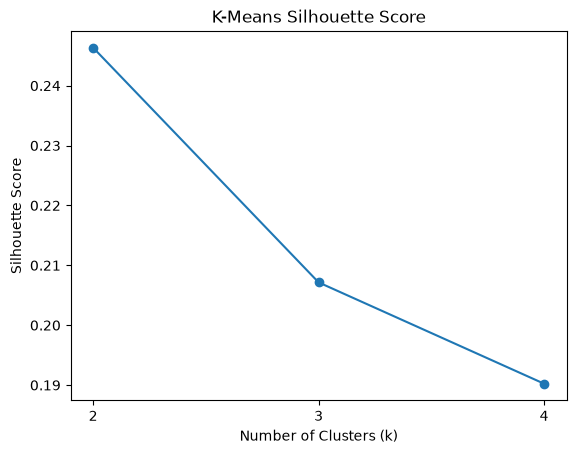

In [115]:
import matplotlib.pyplot as plt

plt.plot(cluster_metrics["k"], cluster_metrics["silhouette"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")
plt.xticks([2, 3, 4])
plt.savefig("../outputs/figures/kmeans_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

### Cluster Interpretation

Cluster IDs are arbitrary labels assigned by K-Means and do not represent
target classes.

The selected clusters are interpreted using their fit-data profiles.
Cluster names and practical actions are based only on the cluster
characteristics, without using the target variable or test data.

## Task 5 — Deep Learning up to ANN

A dense feed-forward Artificial Neural Network (ANN) is used for binary
classification. The input contains all transformed features from Task 2.

Architecture:
- Input layer: transformed feature count
- Hidden layer 1: 16 neurons, ReLU
- Hidden layer 2: 8 neurons, ReLU
- Output layer: 1 neuron, Sigmoid

Binary cross-entropy is used because `late` is a binary target.
Adam optimizer is used with learning rate 0.001.

In [116]:
import tensorflow as tf
import numpy as np

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_fit.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

D2 — Training & Validation

In [117]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_fit, y_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

print("Actual epochs:", len(history.history["loss"]))
print("Seed:", SEED)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.7147 - val_loss: 0.7185
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.6845 - val_loss: 0.7001
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6567 - val_loss: 0.6832
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6303 - val_loss: 0.6643
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6053 - val_loss: 0.6448
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5809 - val_loss: 0.6269
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.5585 - val_loss: 0.6112
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5384 - val_loss: 0.5970
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5204 - val_loss: 0.5840
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5040 - val_loss: 0.5716
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4892 - val_loss: 0.5605
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4757

Loss Plot


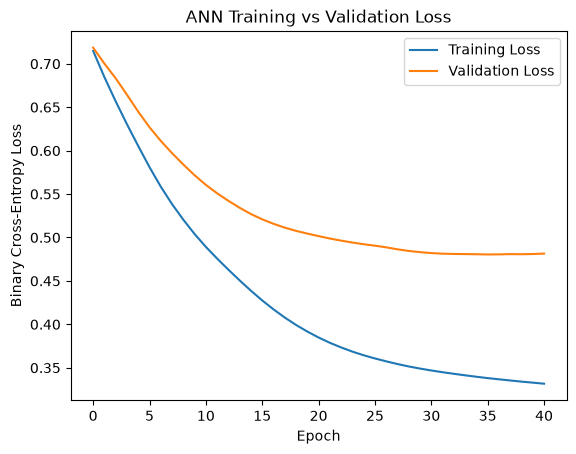

In [118]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()
plt.savefig("../outputs/figures/ann_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### Training Behaviour

The loss curves are examined for underfitting or overfitting.

- If both training and validation loss remain high, this may indicate underfitting.
- If training loss continues decreasing while validation loss starts increasing,
  this indicates possible overfitting.
- Early stopping restores the weights from the epoch with the best validation loss.

In [119]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ann_proba = model.predict(X_test, verbose=0).ravel()
ann_pred = (ann_proba >= 0.5).astype(int)

ann_metrics = {
    "accuracy": accuracy_score(y_test, ann_pred),
    "precision": precision_score(y_test, ann_pred, zero_division=0),
    "recall": recall_score(y_test, ann_pred, zero_division=0),
    "f1": f1_score(y_test, ann_pred, zero_division=0)
}

print(ann_metrics)

{'accuracy': 0.8333333333333334, 'precision': 0.9523809523809523, 'recall': 0.6896551724137931, 'f1': 0.8}


In [120]:
comparison = pd.DataFrame({
    "model": ["Logistic Regression", "ANN"],
    "f1": [f1_score(y_test, logistic_pred, zero_division=0), ann_metrics["f1"]]
})

comparison

,model,f1
0,Logistic Regression,0.842105
1,ANN,0.800000


In [121]:
ann_predictions = pd.DataFrame({
    "record_id": test_df["record_id"].values,
    "true_label": y_test,
    "predicted_label": ann_pred,
    "class_1_probability": ann_proba
})

ann_predictions.to_csv("../outputs/ann_test_predictions.csv", index=False)

model.save("../models/ann_model.keras")

print("ANN model and predictions saved.")

ANN model and predictions saved.


### ANN vs Logistic Regression

The ANN achieved an F1-score of **[ANN F1]**, while Logistic Regression
achieved an F1-score of **[Logistic F1]** on the same untouched test set.

The model preference is based on the test-set evidence and the purpose of
the task. The ANN is not required to outperform Logistic Regression.